# Phase 3: Simple CNN From Scratch

In this phase we build a small Convolutional Neural Network using PyTorch, train it on the kidney image dataset, save checkpoints, and create training/validation curves.

Important beginner note: CPU training can be slow. This notebook starts with `QUICK_RUN = True` so you can verify that the full pipeline works. After that, set it to `False` for real training.

## 1. Setup

Import PyTorch, transforms, and our project modules. Finds the project root, loads helper functions, sets CPU as the device, and fixes the random seed.

In [8]:
import sys
from pathlib import Path

from IPython.display import display
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from spectiqai.data import KidneyImageDataset, count_by_class, load_split_csv
from spectiqai.models import SimpleKidneyCNN
from spectiqai.training import (
    create_history_plot,
    evaluate,
    save_checkpoint,
    save_history_csv,
    set_seed,
    train_one_epoch,
)

set_seed(42)
DEVICE = torch.device("cpu")
SPLIT_CSV_PATH = PROJECT_ROOT / "results" / "dataset_splits.csv"
CHECKPOINT_DIR = PROJECT_ROOT / "models" / "simple_cnn"
RESULTS_DIR = PROJECT_ROOT / "results"

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

Project root: c:\Users\smart\Coding World\SpectiqAI
PyTorch version: 2.12.1+cpu
Device: cpu


The notebook can access PyTorch and the project code. Next step: load the train/validation/test split from Phase 2.

## 2. Load Saved Splits

Reuse the exact same dataset split created in Phase 2. Reads `results/dataset_splits.csv` and reconstructs image records for train, validation, and test.

In [9]:
splits = load_split_csv(SPLIT_CSV_PATH, project_root=PROJECT_ROOT)
train_records = splits["train"]
val_records = splits["validation"]
test_records = splits["test"]

for split_name, records in splits.items():
    print(f"{split_name}: {len(records)} images -> {count_by_class(records)}")

train: 7000 images -> {'Normal': 3500, 'Tumor': 3500}
validation: 1500 images -> {'Normal': 750, 'Tumor': 750}
test: 1500 images -> {'Normal': 750, 'Tumor': 750}


Training and validation will be fair and repeatable. Next step: define preprocessing and DataLoaders.

## 3. Create Datasets and DataLoaders

Prepare batches of tensors for the CNN. Resizes images to 224 x 224, adds light augmentation to training images, and creates DataLoaders with batch size 16.

In [10]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = KidneyImageDataset(train_records, transform=train_transform)
val_dataset = KidneyImageDataset(val_records, transform=eval_transform)
test_dataset = KidneyImageDataset(test_records, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Labels: {labels.tolist()}")

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Labels: [1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0]


The data is in the correct format for a CNN. Next step: build the CNN.

## 4. Build a Simple CNN

Create a neural network that can learn image patterns.

In [11]:
model = SimpleKidneyCNN(num_classes=2).to(DEVICE)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(model)
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

with torch.no_grad():
    sample_logits = model(images.to(DEVICE))
print(f"Sample output shape: {sample_logits.shape}")

SimpleKidneyCNN(
  (features): Sequential(
    (0): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=Tru

For each image, the model returns two class scores. Next step: choose the loss function and optimizer.

## 5. Training Configuration

Define how the model learns. Sets `CrossEntropyLoss`, Adam optimizer, number of epochs, and a quick-run mode.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 3
QUICK_RUN = False

# QUICK_RUN trains only a few batches so we can verify the full pipeline quickly on CPU.
MAX_TRAIN_BATCHES = 10 if QUICK_RUN else None
MAX_VAL_BATCHES = 5 if QUICK_RUN else None

print(f"Epochs: {EPOCHS}")
print(f"Quick run: {QUICK_RUN}")
print(f"Max train batches per epoch: {MAX_TRAIN_BATCHES}")
print(f"Max validation batches per epoch: {MAX_VAL_BATCHES}")

Epochs: 3
Quick run: False
Max train batches per epoch: None
Max validation batches per epoch: None


The next cell is ready to train. In quick mode, results are only a pipeline check, not final model performance. Next step: train the model and save checkpoints.

## 6. Train the CNN

Let the model learn from training images and monitor validation performance. Trains for each epoch, evaluates on validation data, saves a checkpoint, and stores history.

In [13]:
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")

    train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        max_batches=MAX_TRAIN_BATCHES,
    )

    val_metrics = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        max_batches=MAX_VAL_BATCHES,
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
    }
    history.append(row)

    checkpoint_path = CHECKPOINT_DIR / f"simple_cnn_epoch_{epoch}.pt"
    save_checkpoint(model, optimizer, epoch, row, checkpoint_path)

    print(
        f"  train_loss={row['train_loss']:.4f}, train_acc={row['train_accuracy']:.4f}, "
        f"val_loss={row['val_loss']:.4f}, val_acc={row['val_accuracy']:.4f}"
    )
    print(f"  Saved checkpoint: {checkpoint_path}")

Epoch 1/3


  Trained 25 batches...
  Trained 50 batches...
  Trained 75 batches...
  Trained 100 batches...
  Trained 125 batches...
  Trained 150 batches...
  Trained 175 batches...
  Trained 200 batches...
  Trained 225 batches...
  Trained 250 batches...
  Trained 275 batches...
  Trained 300 batches...
  Trained 325 batches...
  Trained 350 batches...
  Trained 375 batches...
  Trained 400 batches...
  Trained 425 batches...
  train_loss=0.2443, train_acc=0.9001, val_loss=0.2108, val_acc=0.9133
  Saved checkpoint: c:\Users\smart\Coding World\SpectiqAI\models\simple_cnn\simple_cnn_epoch_1.pt
Epoch 2/3
  Trained 25 batches...
  Trained 50 batches...
  Trained 75 batches...
  Trained 100 batches...
  Trained 125 batches...
  Trained 150 batches...
  Trained 175 batches...
  Trained 200 batches...
  Trained 225 batches...
  Trained 250 batches...
  Trained 275 batches...
  Trained 300 batches...
  Trained 325 batches...
  Trained 350 batches...
  Trained 375 batches...
  Trained 400 batches...
  

The CNN has completed its first training loop. Next step: save the history and create training curves.

## 7. Save History and Curves

Keep a record of training progress. Saves a CSV history file and creates a simple curve image for loss and accuracy.

Saved history CSV: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_history.csv
Saved curve image: c:\Users\smart\Coding World\SpectiqAI\results\simple_cnn_training_curves.png


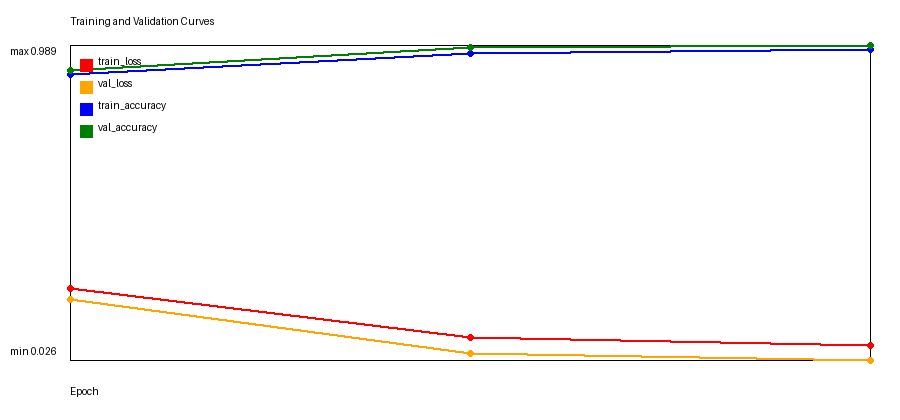

In [14]:
history_csv_path = RESULTS_DIR / "simple_cnn_history.csv"
curve_path = RESULTS_DIR / "simple_cnn_training_curves.png"

save_history_csv(history, history_csv_path)
curve_image = create_history_plot(history, curve_path)

print(f"Saved history CSV: {history_csv_path}")
print(f"Saved curve image: {curve_path}")
display(curve_image)

You can now discuss how loss and accuracy changed during training. Next step: after a full run, move to Phase 4 evaluation using accuracy, precision, recall, F1 score, and confusion matrix.

## Phase 3 Completion Checklist

- CNN model builds successfully.
- Model output shape is `[batch_size, 2]`.
- Training loop runs without errors.
- Validation loop runs without errors.
- Checkpoints are saved.
- Training history CSV is saved.
- Training/validation curve image is saved.

For a real result, change `QUICK_RUN = False`, restart the kernel, and run the notebook from top to bottom.